In [1]:
import sys
import git
import pathlib

# Set up the PROJ_ROOT variable
PROJ_ROOT_PATH = pathlib.Path(git.Repo('.', search_parent_directories=True).working_tree_dir)
PROJ_ROOT =  str(PROJ_ROOT_PATH)
if PROJ_ROOT not in sys.path:
    sys.path.insert(0, PROJ_ROOT)

# Explicitly add the current notebook's directory
CURRENT_DIR = str(pathlib.Path().absolute())
if CURRENT_DIR not in sys.path:
    sys.path.insert(0, CURRENT_DIR)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
# Experiment Name and Locations
exp_name_path = {
    "ff-fc-delft-hemt-lp_mn-kide-pd_MXC": PROJ_ROOT_PATH / "notebooks" / "experiments" / "optical" ,
    "ff-fc-delft-hemt-lp_mn-kide-pd_MXC_76": PROJ_ROOT_PATH / "notebooks" / "experiments" / "optical" ,
    "ff-fc-delft-hemt-lp_mn-kide-pd_MXC_81": PROJ_ROOT_PATH / "notebooks" / "experiments" / "optical" ,
    "ff-fc-delft-hemt-lp_mn-kide-pd_MXC_86": PROJ_ROOT_PATH / "notebooks" / "experiments" / "optical",
}

In [4]:
# Load dataframes
df_dict = {}
pq_dict = {}
for exp_name in exp_name_path.keys():
    # Get file path
    exp_dir = exp_name_path[exp_name]
    file_path = exp_dir / exp_name / f"{exp_name}.pkl"
    # Read dataframe
    df = pd.read_pickle(file_path)
    df_dict[exp_name] = df

    pqfname =  exp_dir / exp_name / f"PQ_{exp_name}.pkl"
    df_pq =  pd.read_pickle(pqfname)
    pq_dict[exp_name] = df_pq.iloc[0].tolist()

In [5]:
possible_physical_qubits = []
for exp_name in exp_name_path.keys():
    possible_physical_qubits.append(pq_dict[exp_name][-1])

In [6]:
pq_dict

{'ff-fc-delft-hemt-lp_mn-kide-pd_MXC': [20008, 11624, 54464, 23904, 2704],
 'ff-fc-delft-hemt-lp_mn-kide-pd_MXC_76': [20008, 11624, 54464, 23904, 4624],
 'ff-fc-delft-hemt-lp_mn-kide-pd_MXC_81': [20008, 11624, 54464, 23904, 7680],
 'ff-fc-delft-hemt-lp_mn-kide-pd_MXC_86': [20008, 11624, 54464, 23904, 12216]}

In [7]:
from library.utils import fontstyle, style_map

title_font, axis_label_font, tick_label_font, legend_font, text_font = fontstyle

# Define fallbacks (only used if a stack tuple isn’t in style_map)
# fallback_colors = plt.cm.tab20.colors  # a nice, long qualitative palette
# fallback_hatches = ['/', '\\', 'x', '-', '+', 'o', 'O', '.', '*']  # repeats cyclically
fallback_color = 'white'
fallback_hatch = '//'

IndexError: list index out of range

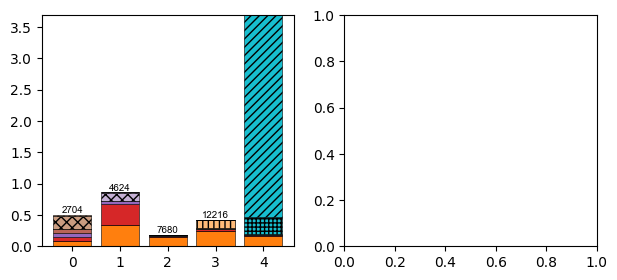

In [8]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(7.16, 3))

# Plot subfigure 1
ax = axs[0]
df_plot = df_dict["ff-fc-delft-hemt-lp_mn-kide-pd_MXC"]
title = "1Q:-71 dBm, 2Q:-66 dBm"
# for (ax, df_plot, possible_physical_qubits, title) in [axs[0], df_dict["ff-fc-delft-hemt-lp_mn-kide-pd_MXC66"], [11728,60466, 258981, 2723], "PD@MXC"]:
# Columns: MultiIndex with levels (Cable, Component, Operation)
cols = list(df_plot.columns)

# Index: temperature stages (e.g., "4K", "Still", "CP", "MXC")
# X positions and labels (temperature stages)
x = np.arange(len(df_plot.index))
xticklabels = ["50K", "4K", "Still", "CP", "MXC" ]

# Create the figure/axes

# Build the stacked bars
bottom = np.zeros(len(x), dtype=float)

for i, col in enumerate(cols):
    values = df_plot[col].astype(float).values

    # pull style from style_map if present, else fallback
    style = style_map.get(col, {})
    color = style.get('color', fallback_color)
    hatch = style.get('hatch', fallback_hatch)

    # readable label in legend
    label = f"{col[0]} | {col[1]} | {col[2]}"

    bars = ax.bar(
        x,
        values,
        bottom=bottom,
        label=label,
        color=color,
        edgecolor='black',
        linewidth=0.4
    )
    # apply hatch to each rectangle
    for b in bars:
        b.set_hatch(hatch)

    bottom += values  # update stack baseline


# Display no. of supported qubits on top of the bar
totals = df_plot.sum(axis=1)  # Sum over column. Get bar height
for i, total in enumerate(totals):
    ax.text(i, total, f'{possible_physical_qubits[i]}', ha='center', va='bottom', fontproperties=text_font)

# Draw horizantal line at y=1
ax.axhline(y=1, color='k', linestyle='--',linewidth=0.6)

# Axis cosmetics
# Set titles 
ax.set_title(title, fontproperties=axis_label_font)
ax.set_xlabel("Temperature Stage", fontproperties=axis_label_font)
ax.set_ylabel("Normalized Heat Load", fontproperties=axis_label_font)
ax.set_xticks(x)
ax.set_xticklabels(xticklabels, fontproperties=tick_label_font, rotation=0)
for label in ax.get_yticklabels() :
    label.set_fontproperties(tick_label_font)
ax.set_ylim(0, max(totals)*1.1) # Set max y-value to be slightly higher than the tallest bar

######################################
# Plot subfigure 2
# Load Dataframes
exp_list = list(exp_name_path.keys())[1:]
rows_MXC = []
for exp_name in exp_list :
    # Get file path
    exp_dir = exp_name_path[exp_name]
    file_path = exp_dir / exp_name / f"{exp_name}.pkl"
    # Read dataframe
    df = pd.read_pickle(file_path)
    # Extract only the values for 4K
    rows_MXC.append(df.loc["MXC"])

df_MXC = pd.DataFrame(rows_MXC, index=exp_list).fillna(0)

# 1) Decide the plotting order of stacks (columns)
# Reorder columns: PASSIVE first
original_columns = df_MXC.columns.tolist()
passive_cols = [col for col in df_MXC.columns if col[1] == 'PASSIVE']
active_cols  = [col for col in df_MXC.columns if col[1] != 'PASSIVE']
reordered_columns = passive_cols + active_cols

# Reorder df_plot accordingly
df_MXC = df_MXC[reordered_columns]
cols = list(df_MXC.columns)

# 5) X positions and labels (temperature stages)
x = np.arange(len(df_MXC.index))
# xticklabels = df_plot.index.astype(str)
# xticklabels = ["4K", "Still (1K)", "CP (100 mK)", "MXC (10 mK)" ]
xticklabels = ["-76/-71","-81/-76","-86/-81"]

ax = axs[1]
title = "Variations of 1Q/2Q power @ MXC"

# 7) Build the stacked bars
bottom = np.zeros(len(x), dtype=float)

for i, col in enumerate(cols):
    values = df_MXC[col].astype(float).values

    # pull style from style_map if present, else fallback
    style = style_map.get(col, {})
    color = style.get('color', fallback_color)
    hatch = style.get('hatch', fallback_hatch)

    # readable label in legend
    label = f"{col[0]} | {col[1]} | {col[2]}"

    bars = ax.bar(
        x,
        values,
        bottom=bottom,
        label=label,
        color=color,
        edgecolor='black',
        linewidth=0.4
    )
    # apply hatch to each rectangle
    for b in bars:
        b.set_hatch(hatch)

    bottom += values  # update stack baseline

# Display no. of supported qubits on top of the bar
totals = df_MXC .sum(axis=1)  # Sum over column. Get bar height
for i, total in enumerate(totals):
    ax.text(i, total, f'{possible_physical_qubits[i+1]}', ha='center', va='bottom', fontproperties=text_font)

# Draw horizantal line at y=1
ax.axhline(y=1, color='k', linestyle='--',linewidth=0.6)

# 8) Axis cosmetics
# Set titles 
ax.set_title(title, fontproperties=title_font)
ax.set_xlabel("Qubit Power at MXC (1Q/2Q) in dBm", fontproperties=axis_label_font)
ax.set_ylabel("Normalized Heat Load at MXC", fontproperties=axis_label_font)
ax.set_xticks(x)
ax.set_xticklabels(xticklabels, fontproperties=tick_label_font, rotation=0)
for label in ax.get_yticklabels() :
    label.set_fontproperties(tick_label_font)
ax.set_ylim(0, max(totals) + 1.5) # Set max y-value to be slightly higher than the tallest bar

# 9) Legend: shrink and place outside
axs[0].legend(ncol=1, 
          bbox_to_anchor=(0,1),
          loc='upper left',
          prop=legend_font,
          frameon=False,
          borderaxespad=0.)

ax.margins(x=0.02)
plt.tight_layout()
plt.savefig(f"./optical_kide.png",dpi=600)
plt.show()


In [9]:
possible_physical_qubits

[2704, 4624, 7680, 12216]

In [10]:
totals

Temp
50K      0.499627
4K       0.860127
Still    0.183585
CP       0.418209
MXC      3.688554
dtype: float64